In [51]:
import re
import regex
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from collections import Counter
from os import path
from PIL import Image
import datetime
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator


In [52]:
def startswithDateandTimeAndroid(s):
  pattern=r'^\d{1,2}/\d{1,2}/\d{2,4}, \d{1,2}:\d{2}(?: [apAP][mM])? -'
  result=re.match(pattern,s)
  if result:
    return True
  return False

In [53]:
def FindAuthor(s):
  s=s.split(":",1)
  if len(s)==2:
    return True
  else:
    return False

In [94]:
def getDataPointAndroid(line):
    # Split once at the first ' - '
    splitline = line.split(' - ', 1)
    if len(splitline) < 2:
        return None, None, None, line  # fallback

    dateTime = splitline[0].strip()
    message = splitline[1].strip()

    # Separate date and time
    if ',' in dateTime:
        date, time = dateTime.split(',', 1)
    else:
        date, time = dateTime, ""

    author = None
    if ':' in message:  # Author + message
        splitMessage = message.split(':', 1)  # split only once!
        author = splitMessage[0].strip()
        message = splitMessage[1].strip()
    return date.strip(), time.strip(), author, message


In [55]:
def getDataPoints(s):
    # iOS format: [26/01/2020, 4:19:03 pm] Author: message
    splitLine = s.split(']', 1)  # split once
    dateTime = splitLine[0].strip('[').strip()

    if ',' in dateTime:
        date, time = dateTime.split(',', 1)
    else:
        parts = dateTime.split(' ', 1)
        date = parts[0]
        time = parts[1] if len(parts) > 1 else ""

    message = splitLine[1].strip() if len(splitLine) > 1 else ""

    author = None
    if FindAuthor(message):
        splitMessage = message.split(':', 1)
        author = splitMessage[0].strip()
        message = splitMessage[1].strip()

    return date.strip(), time.strip(), author, message


In [95]:
!pip install emoji


In [96]:
import emoji

def split_count(text):
    return [ch for ch in text if emoji.is_emoji(ch)]


In [101]:
parsedData = []
ConversationPath = '/content/whatsapp-chat-data.txt'

with open(ConversationPath, encoding="utf-8") as fp:
    device = ' '
    first = fp.readline()
    print(first)

    if '[' in first:
        device = 'ios'
    else:
        device = 'android'

    fp.readline()  # skip second line

    messageBuffer = []
    date, time, author = None, None, None

    while True:
        line = fp.readline()
        if not line:
            break

        line = line.strip()

        if device == 'ios':
          if startswithDateandTimeios(line):
              if len(messageBuffer) > 0:
                  parsedData.append([date, time, author, ' '.join(messageBuffer)])
              messageBuffer.clear()
              date, time, author, message = getDataPoints(line)   # iOS parser
              messageBuffer.append(message)
          else:
              messageBuffer.append(line)

        else:  # android
          if startswithDateandTimeAndroid(line):
              if len(messageBuffer) > 0:
                  parsedData.append([date, time, author, ' '.join(messageBuffer)])
              messageBuffer.clear()
              date, time, author, message = getDataPointAndroid(line)   # ✅ use Android parser
              messageBuffer.append(message)
          else:
              messageBuffer.append(line)


In [102]:
print(messages_df['Author'].unique()[:20])


[None "Mudita Ma'am"]


In [78]:

line = "26/01/2020, 4:19 pm - Author: Hello!"
print(startswithDateandTimeAndroid(line))


True


In [79]:
if device=="android":
  df = pd.DataFrame(parsedData, columns=['Date', 'Time', 'Author', 'Message'])
  df['Date'] = pd.to_datetime(df['Date'])

  URLPATTERN = r'(https?://\S+)'
  df['urlcount'] = df.Message.apply(lambda x: re.findall(URLPATTERN, x)).str.len()
else:
  df = pd.DataFrame(parsedData, columns=['Date', 'Time', 'Message'])
  df=df.dropna()
  df['Date']=df['Date'].apply(dateconv)
  df['Date']=pd.to_datetime(df['Date'],format='%Y-%m-%d')

  URLPATTERN = r'(https?://\S+)'
  df['urlcount'] = df.Message.apply(lambda x: re.findall(URLPATTERN, x)).str.len()


/tmp/ipython-input-1586482735.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [80]:

df.tail(20)

,Date,Time,Author,Message,urlcount
13517,2020-10-02,1:27 am - +91 73032 50500: <Media omitted>,None,,0
13518,2020-10-02,"1:46 am - Darshan Rander (TSEC, IT): Lucky u",None,,0
13519,2020-10-02,1:47 am - +91 73032 50500: Darshan brooo,None,,0
13520,2020-10-02,1:47 am - +91 73032 50500: Yeh kar na dost,None,,0
13521,2020-10-02,1:47 am - +91 73032 50500: ..,None,,0
13522,2020-10-02,1:47 am - +91 73032 50500: ..,None,,0
13523,2020-10-02,1:47 am - +91 73032 50500: Mil jayegaa,None,,0
13524,2020-10-02,"1:47 am - Darshan Rander (TSEC, IT): Okk mene ...",None,,0
13525,2020-10-02,"1:49 am - Shubham Chettiar (TSEC CS, TE): Yeah...",None,After that most of them texted me in the even...,0
13526,2020-10-02,"1:49 am - Darshan Rander (TSEC, IT): Okk firse...",None,,0


In [81]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13537 entries, 0 to 13536
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      13537 non-null  datetime64[ns]
 1   Time      13537 non-null  object        
 2   Author    2 non-null      object        
 3   Message   13537 non-null  object        
 4   urlcount  13537 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 528.9+ KB


In [82]:
total_messages=df.shape[0]
print(total_messages)

13537


In [83]:
media_messages=df[df['Message']=='<Media omitted>'].shape[0]
print(media_messages)

0


In [84]:
URL_PATTERN='r(https?://\S+)'
df['urlcount']=df.Message.apply(lambda x: re.findall(URLPATTERN,x)).str.len()

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipython-input-979384469.py:1: SyntaxWarning: invalid escape sequence '\S'
  URL_PATTERN='r(https?://\S+)'


In [85]:
link_messages=df[df['urlcount']>0]
deleted_messages=df[(df["Message"]=="You deleted this messgage")|(df["Message"]=="This message was deleted")]
media_messages=df[(df["Message"]=='  <Media omitted>')|(df["Message"]==' image omitted ')|(df["Message"]==' video omitted  ')|(df["Message"]=='  GIF omitted  ')|(df["Message"]=='  audio omitted  ')|(df['Message']=='  sticker omitted  ')]
messages_df=df.drop(link_messages.index)
messages_df=messages_df.drop(deleted_messages.index)
messages_df=messages_df.drop(media_messages.index)

In [86]:
messages_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13310 entries, 0 to 13536
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      13310 non-null  datetime64[ns]
 1   Time      13310 non-null  object        
 2   Author    2 non-null      object        
 3   Message   13310 non-null  object        
 4   urlcount  13310 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 623.9+ KB


In [87]:
messages_df['Letter_Count']=messages_df['Message'].apply(lambda s:len(s))
messages_df['Word_Count']=messages_df['Message'].apply(lambda s:len(s.split(' ')))
messages_df['MessageCount']=1

In [88]:
messages_df.head()

,Date,Time,Author,Message,urlcount,Letter_Count,Word_Count,MessageCount
0,2020-01-27,7:31 pm - +91 96536 93868: Give it a try ....,None,,0,0,1,1
1,2020-01-27,"7:31 pm - Dheeraj Lalwani (TSEC, CS): Alright",None,,0,0,1,1
2,2020-01-27,"7:32 pm - Dheeraj Lalwani (TSEC, CS): We can m...",None,,0,0,1,1
3,2020-01-27,7:32 pm - +91 96536 93868: Sure,None,,0,0,1,1
4,2020-01-27,"7:32 pm - Dheeraj Lalwani (TSEC, CS): Everyday...",None,,0,0,1,1


In [89]:
frnds=messages_df.Author.unique()
for i in range(len(frnds)):
  req_df=messages_df[messages_df["Author"]==frnds[i]]
  print(f'{frnds[i]}: {req_df.shape[0]}')
  words_per_message=(np.sum(req_df['Word_Count']))/req_df.shape[0]
  print(f'Average words per message: {words_per_message:.3f}')
  media=media_messages[media_messages["Author"]==frnds[i]].shape[0]
  print(f'Media messages: {media}')
  links=sum(link_messages[link_messages["Author"]==frnds[i]]['urlcount'])
  print(f'Links sent: {links}')
  print()


None: 0
Average words per message: nan
Media messages: 0
Links sent: 0

Mudita Ma'am: 2
Average words per message: 20.500
Media messages: 0
Links sent: 0



/tmp/ipython-input-2530762006.py:5: RuntimeWarning: invalid value encountered in scalar divide
  words_per_message=(np.sum(req_df['Word_Count']))/req_df.shape[0]


In [90]:
from datetime import datetime

def parse_time(row):
    date_str = str(row['Date'])
    time_val = row['Time']

    if pd.isna(time_val):  # skip missing times
        return pd.NaT

    time_str = str(time_val).strip().lower()
    try:
        # Try 12-hour format (Android)
        dt = datetime.strptime(f"{date_str} {time_str}", "%d/%m/%Y %I:%M %p")
    except:
        try:
            # Try 24-hour format (iOS)
            dt = datetime.strptime(f"{date_str} {time_str}", "%d/%m/%Y %H:%M")
        except:
            dt = pd.NaT
    return dt

# Apply function
messages_df['DateTime'] = messages_df.apply(parse_time, axis=1)

# Extract hour
messages_df['Hour'] = messages_df['DateTime'].dt.hour

# Check
print("Rows failed to parse:", messages_df['DateTime'].isna().sum())

# Plot if any valid data
if messages_df['Hour'].notna().sum() > 0:
    messages_df['Hour'].value_counts().sort_index().plot.bar(figsize=(10,5))
    plt.xlabel("Hour of Day")
    plt.ylabel("Message Count")
    plt.title("Message Distribution by Hour")
    plt.show()
else:
    print("No valid time data to plot.")


Rows failed to parse: 13310
No valid time data to plot.


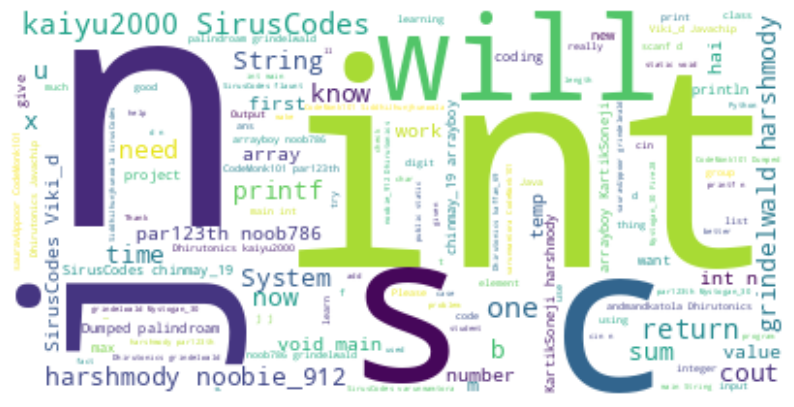

In [91]:
text = " ".join(msg for msg in messages_df['Message'])
wordcloud = WordCloud(stopwords=STOPWORDS, background_color="white").generate(text)

plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


In [93]:
print(messages_df['Author'].unique())


[None "Mudita Ma'am"]


In [92]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Authors from your uploaded chat
authors = [
    'Chirag Sharma (TSEC, CS)',
    'Tanay Kamath (TSEC, CS)',
    'Saket (TSEC, CS)',
    'Darshan Rander (TSEC, IT)',
    'Dheeraj Lalwani (TSEC, CS)'
]

for author in authors:
    dummy_df = messages_df[messages_df['Author'] == author]

    # Remove media and deleted messages
    clean_messages = dummy_df['Message'].dropna()
    clean_messages = clean_messages[
        ~clean_messages.str.contains("Media omitted|This message was deleted", na=False)
    ]

    text = " ".join(msg for msg in clean_messages)

    if text.strip():  # Only if there's valid text
        wordcloud = WordCloud(stopwords=STOPWORDS, background_color="white", max_words=200).generate(text)
        plt.figure(figsize=(10,10))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")
        plt.title(author)
        plt.show()
    else:
        print(f"No valid text messages found for {author}")


No valid text messages found for Chirag Sharma (TSEC, CS)
No valid text messages found for Tanay Kamath (TSEC, CS)
No valid text messages found for Saket (TSEC, CS)
No valid text messages found for Darshan Rander (TSEC, IT)
No valid text messages found for Dheeraj Lalwani (TSEC, CS)
